# Insider Threat Detection Using Random Forest
This notebook predicts malicious employee behavior using behavioral and access data.
- Dataset: `insider_threat_clean_dataset.csv` (~118k records)
- Goal: Detect `is_malicious` employees
- Highlights: Random Forest Model with class imbalance handling, ROC-AUC evaluation, feature importance

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

sns.set_style("whitegrid")

# Load Dataset & Inspect

We load the CSV dataset and separate the **target variable (`is_malicious`)** from input features.  
We also identify the **categorical columns** for one-hot encoding.

In [2]:
# Load dataset
df = pd.read_csv("insider_threat_clean_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

# Separate features and target
y = df["is_malicious"]
X = df.drop("is_malicious", axis=1)

# Identify categorical columns
categorical_columns = [
    "employee_department",
    "employee_campus",
    "employee_position",
    "employee_origin_country"
]

Dataset shape: (118614, 22)
      employee_department employee_campus employee_position  \
0  Engineering Department        Campus C   Design Engineer   
1  Engineering Department        Campus C   Design Engineer   
2  Engineering Department        Campus C   Design Engineer   
3  Engineering Department        Campus C   Design Engineer   
4  Engineering Department        Campus C   Design Engineer   

   employee_seniority_years  is_contractor  employee_classification  \
0                        22              0                        2   
1                        22              0                        2   
2                        22              0                        2   
3                        22              0                        2   
4                        22              0                        2   

   has_foreign_citizenship  has_criminal_record  has_medical_history  \
0                        0                    0                    0   
1                     

# Preprocessing & Random Forest Pipeline

- One-hot encode categorical features  
- Use `RandomForestClassifier` with `class_weight='balanced'` to handle class imbalance  
- Build a scikit-learn pipeline

In [3]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],
    remainder="passthrough"
)

# Random Forest model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=1,
    class_weight='balanced'  # Address class imbalance
)

# Build pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

# Split Data & Train Model

Split the data into **80% training** and **20% testing**, then fit the pipeline.

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

# Train the model
print("\nTraining model...")
pipeline.fit(X_train, y_train)

Training size: (94891, 21)
Test size: (23723, 21)

Training model...


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Model Evaluation

- Accuracy & classification report  
- Confusion matrix  
- ROC curve and AUC score


Model Accuracy:
0.9627787379336509

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     22431
           1       0.62      0.82      0.71      1292

    accuracy                           0.96     23723
   macro avg       0.80      0.90      0.84     23723
weighted avg       0.97      0.96      0.97     23723



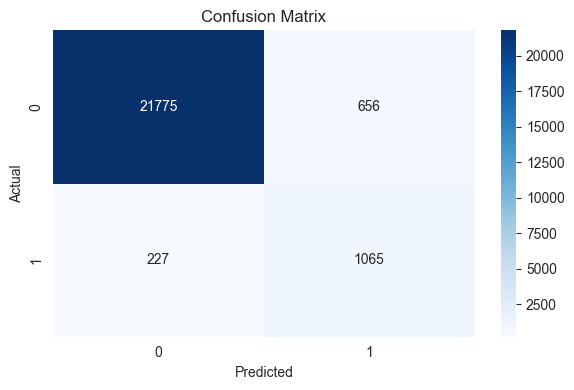


AUC Score: 0.9641106652074963


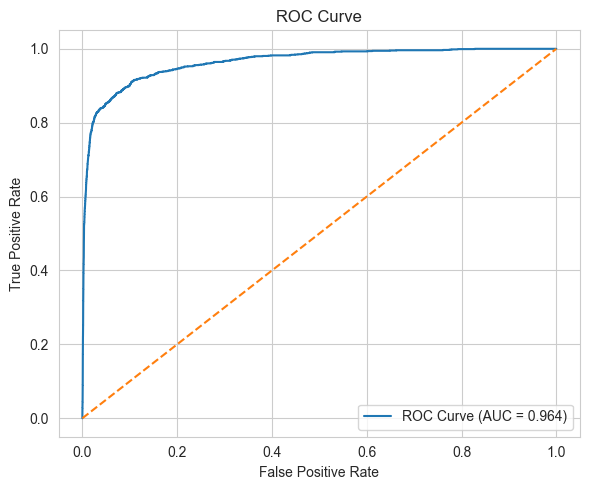

In [5]:
# Predictions
y_pred = pipeline.predict(X_test)

# Accuracy & classification report
print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve + AUC Score
y_probs = pipeline.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
print("\nAUC Score:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.legend()
plt.show()

# Feature Importance

- Identify which features contribute most to malicious behavior predictions  
- Plot the top 10 features


Top 15 Important Features:
                                               feature  importance
102                      remainder__total_files_burned    0.310910
100                     remainder__total_printed_pages    0.142965
108                       remainder__num_unique_campus    0.071297
101             remainder__num_printed_pages_off_hours    0.059525
103                       remainder__burned_from_other    0.059099
107                             remainder__num_entries    0.037431
94                 remainder__employee_seniority_years    0.034005
110                    remainder__entry_during_weekend    0.028407
65                  cat__employee_origin_country_China    0.019615
96                  remainder__employee_classification    0.017661
0      cat__employee_department_Engineering Department    0.015004
41   cat__employee_position_Integration and Testing...    0.012301
106                 remainder__hostility_country_level    0.009852
27               cat__employee_pos

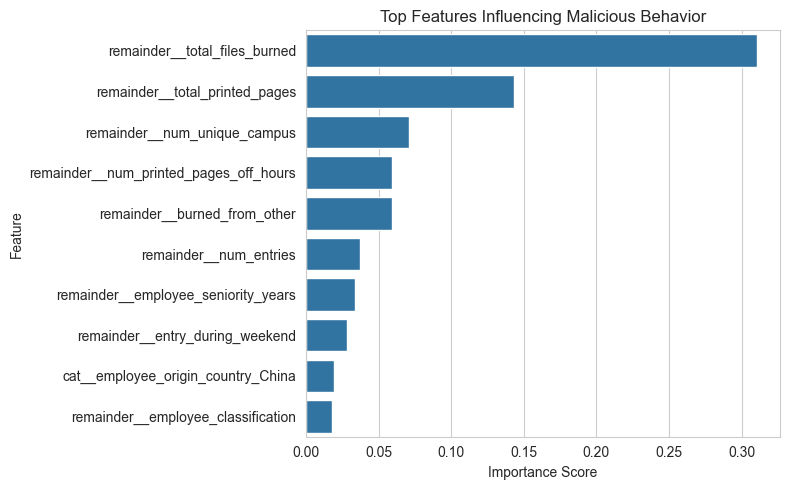

In [6]:
# Get feature names after encoding
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))

# Plot top 10 features
top_features = feature_importance.head(10)
plt.figure(figsize=(8,5))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top Features Influencing Malicious Behavior")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Summary of Findings

**Model Performance:**
- **Accuracy:** 96% – the model predicts most employees correctly.
- **Malicious Employee Recall:** 82% – it catches most of the risky employees.
- **Precision for Malicious Employees:** 62% – some false alarms, but better to catch threats.
- **AUC Score:** 0.96 – the model ranks high-risk employees well.

**Top Features that Affect Predictions:**
- `total_files_burned` – the most important indicator.
- `total_printed_pages` – printing a lot can be risky.
- `num_unique_campus` – visiting multiple campuses is suspicious.
- `num_printed_pages_off_hours` – printing during off hours is a red flag.
- `burned_from_other` – handling other employees’ files could be risky.
- Other factors: number of entries, seniority, weekend activity, department, and country.

**Key Takeaways:**
- Employee behavior like off-hours activity, multi-campus access, and file burning helps identify insider threats.
- Using `class_weight='balanced'` improved detection of rare malicious events.
- The model is interpretable and can help security teams spot risky behavior.

**Conclusion:**
This Random Forest model is simple, effective, and can highlight potential insider threats while giving insight into why certain employees are flagged.